## 1. Imports e Setup

In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import joblib

from functions_new import *
from UQpy.distributions import Uniform, JointIndependent

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False
})



d:\Documentos\ic_victor\myenv\Lib\site-packages\UQpy\__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 2. Carregamento do Modelo

In [2]:
name_best_model = r'D:\Documentos\ic_victor\beam_problem_1\model_NeuralNetwork_MLP_fold_4.pkl'
model = joblib.load(name_best_model)
model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('mlpregressor',
                 MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=2000,
                              random_state=42))])

## 3. Definição da Viga

In [3]:
geo = {
    'b_w [m]': 0.20,
    'h [m]': 0.25,
    'l [m]': 6.00,
    'n bars': 4,
    'phi [m]': 0.0125,
    'ratio d/h': 0.84,
    'cover [m]': 0.015
}

mat = {
    'f_yk [kPa]': 500E3,
    'f_ck [kPa]': 25E3,
    'e_s [kPa]': 200E6,
    'gamma_c': 1.0,
    'gamma_s': 1.0,
    'Type of cement': 2
}

load = {
    'g_k [kN/m]': 5.0,
    'q_k [kN/m]': 2.0,
    'gamma_g': 1.0,
    'gamma_q': 1.0
}

expo = {
    'temp [°C]': 25.0,
    'Relative humidity [%]': 65.0,
    'Installation year': 2000,
    'Exposure conditions': 2,
    'i_corr_20': 2.3 
}

beam_test = Beam(geo, mat, load, expo)

## 4. Validação do Modelo de CO2

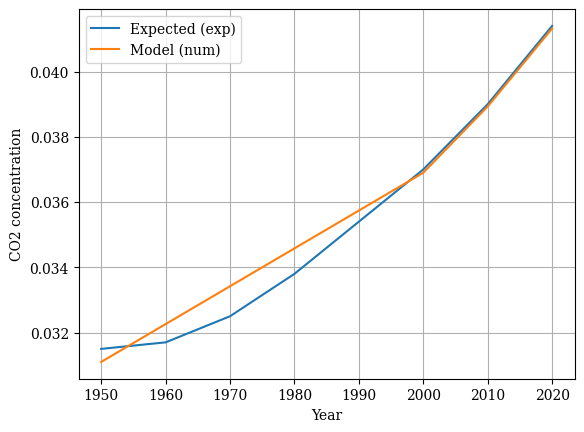

In [4]:
times = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]

co2_exp_values = [0.0315, 0.0317, 0.0325, 0.0338, 0.0354, 0.0370, 0.0390, 0.0414]
co2_num_values = [beam_test.co2_percentage_year(year) for year in times]

plt.figure()
plt.plot(times, co2_exp_values, label='Expected (exp)')
plt.plot(times, co2_num_values, label='Model (num)')
plt.xlabel('Year')
plt.ylabel('CO2 concentration')
plt.legend()
plt.grid()
plt.show()

## 5. Perfil de Carbonatação (único cálculo)

In [5]:
lifetime = 100
profile = beam_test.carbonation_profile(model=model, lifetime=lifetime)
profile

,calendar year,t (years),CO2 (%),carbonation depth (mm)
0,2000,0,0.03690,0.000000
1,2010,10,0.03893,18.183397
2,2020,20,0.04132,26.393642
3,2030,30,0.04407,32.626899
4,2040,40,0.04718,37.909437
5,2050,50,0.05065,42.111630
6,2060,60,0.05448,46.398767
7,2070,70,0.05867,50.679217
8,2080,80,0.06322,54.281524
9,2090,90,0.06813,57.148841


## 6. Amostragem das Variáveis Aleatórias

In [6]:
n_samples = 100
n_latent_samples = 100

cover = Uniform(loc=0.015, scale=0.005)
fck = Uniform(loc=25E3, scale=50E3 - 25E3)
rh = Uniform(loc=20, scale=60)
#TEMPERATURA?


joint = JointIndependent(marginals=[cover, fck, rh])
x = joint.rvs(n_samples)

x

array([[1.94110419e-02, 4.01556360e+04, 5.35076472e+01],
       [1.85284445e-02, 4.24388008e+04, 7.73697595e+01],
       [1.62281910e-02, 2.75014105e+04, 6.55358964e+01],
       [1.50794071e-02, 4.94794962e+04, 2.57913598e+01],
       [1.68765463e-02, 3.14362889e+04, 6.14939125e+01],
       [1.86272470e-02, 3.94791370e+04, 5.80379761e+01],
       [1.96374875e-02, 4.31160905e+04, 4.86173866e+01],
       [1.76933998e-02, 3.37877186e+04, 3.26415239e+01],
       [1.52768519e-02, 4.28777121e+04, 2.86546168e+01],
       [1.64576680e-02, 2.70540533e+04, 5.01957929e+01],
       [1.80967270e-02, 2.91995553e+04, 7.00481334e+01],
       [1.66858587e-02, 4.29739142e+04, 3.72323617e+01],
       [1.80798928e-02, 3.66848017e+04, 2.23945364e+01],
       [1.99442717e-02, 4.08063243e+04, 7.69316405e+01],
       [1.90736939e-02, 3.05779255e+04, 3.79968854e+01],
       [1.67616761e-02, 2.67896709e+04, 2.39529266e+01],
       [1.82010277e-02, 2.76624400e+04, 6.79309512e+01],
       [1.53241626e-02, 4.62560

## 7. Avaliação da Função de Estado

In [7]:
times = np.arange(0, 101, 10)
results = {}

# Parâmetros
n_latent_samples = 100  # Pode aumentar para 1000 para resultados mais precisos
lifetime_max = 100

for t in times:
    print(f'Processing time = {t}')
    
    df = state_limit_function_time_structural(
        x=x,
        names_x_variables=["cover", "fck", "rh"],
        carb_model=model,
        beam_ref=beam_test,
        time_step=t,
        n_latent_samples=n_latent_samples,
        lifetime_max=lifetime_max,
        verbose=True  # Para ver o progresso
    )
    
    results[t] = df
    print(f'  Completed time {t}, shape: {df.shape}')

Processing time = 0
Processing sample 1/100
  Sample 1:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.00 mm
    Mean initiation time = 53.59 years
    Samples that reached cover: 100/100 (100.0%)
    GLAM converged: True
Processing sample 2/100
  Sample 2:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.00 mm
    Mean initiation time = 92.97 years
    Samples that reached cover: 47/100 (47.0%)
    GLAM converged: True
Processing sample 3/100
  Sample 3:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.00 mm
    Mean initiation time = 11.86 years
    Samples that reached cover: 100/100 (100.0%)
    GLAM converged: True
Processing sample 4/100
  Sample 4:
    P(g < 0) = 0.0000
    Mean carbonation depth = 0.00 mm
    Mean initiation time = 100.00 years
    Samples that reached cover: 0/100 (0.0%)
    GLAM converged: True
Processing sample 5/100
  Sample 5:
    P(g < 0) = 0.0100
    Mean carbonation depth = 0.00 mm
    Mean initiation time = 18.21 years
    Samples that re

# 7.5. Validação dos Resultados


VALIDAÇÃO DOS RESULTADOS

TEMPO: 0 anos
  Número de amostras totais: 10000
  Probabilidade de falha P(g < 0): 0.0010
  g - média: 12.8290
  g - desvio padrão: 3.8410
  g - mínimo: -4.1484
  g - máximo: 27.2953
  R - média: 44.4761
  S - média: 31.6471

  ANÁLISE DE CARBONATAÇÃO:
    Amostras que atingiram a armadura: 8352 (83.5%)
    Amostras que NÃO atingiram: 1648 (16.5%)
    Tempo de iniciação - média: 42.38 anos
    Tempo de iniciação - desvio: 25.54 anos
    Tempo de iniciação - percentis (5%, 50%, 95%): [11. 35. 88.]
    Profundidade carbonatação - média: 0.00 mm
    Profundidade carbonatação - desvio: 0.00 mm

  PARÂMETROS GLAM (média):
    lambda 1: 12.9631 ± 0.4711
    lambda 2: 0.3672 ± 0.0547
    lambda 3: 0.1523 ± 0.1017
    lambda 4: 0.2215 ± 0.1340

TEMPO: 10 anos
  Número de amostras totais: 10000
  Probabilidade de falha P(g < 0): 0.0013
  g - média: 12.8795
  g - desvio padrão: 3.8765
  g - mínimo: -2.3462
  g - máximo: 26.2709
  R - média: 44.5106
  S - média: 31.631

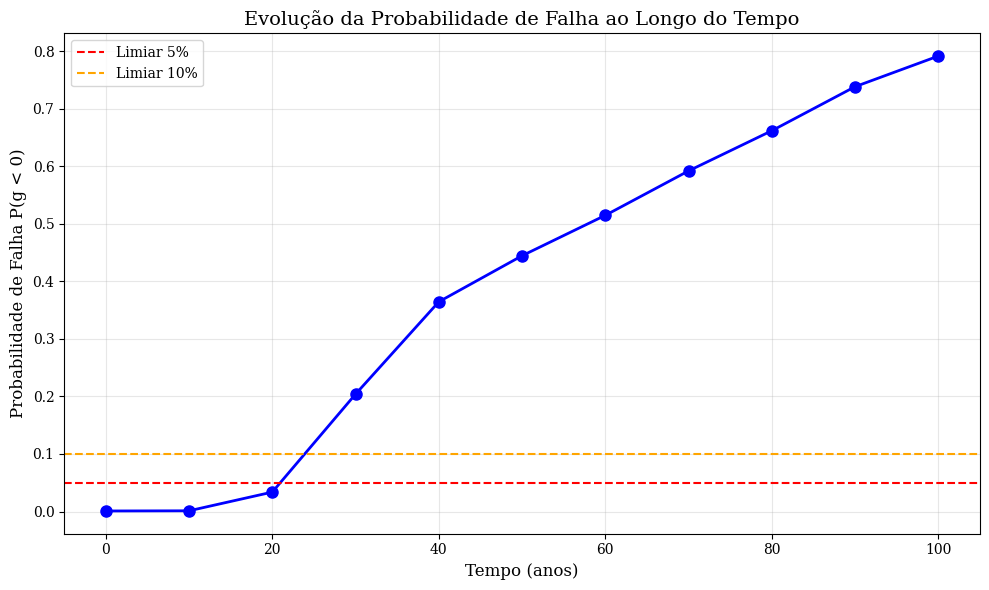

In [8]:
# Se você adicionou a função no functions_.py:
validation_stats = validate_results(results, x, lifetime_max=100)

# Ou se preferir manter a função apenas no notebook, você pode defini-la aqui mesmo
# e depois chamá-la

# Plot adicional: evolução da probabilidade de falha
plt.figure(figsize=(10, 6))
tempos = sorted(results.keys())
prob_falha = [np.mean(results[t]['g'] < 0) for t in tempos]

plt.plot(tempos, prob_falha, 'b-o', linewidth=2, markersize=8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Limiar 5%')
plt.axhline(y=0.10, color='orange', linestyle='--', label='Limiar 10%')
plt.xlabel('Tempo (anos)', fontsize=12)
plt.ylabel('Probabilidade de Falha P(g < 0)', fontsize=12)
plt.title('Evolução da Probabilidade de Falha ao Longo do Tempo', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('probabilidade_falha_evolucao.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Salvando Resultados

In [9]:
for t, df in results.items():
    joblib.dump(df, f"df_time_{t}.pkl")

## 9. Análise do Tempo de Iniciação


ANÁLISE DO TEMPO DE INICIAÇÃO DA CORROSÃO
  Total de amostras analisadas: 110000
  Amostras que atingiram a armadura: 91780 (83.4%)
  Amostras que NÃO atingiram: 18220

  Tempo de iniciação (amostras que atingiram):
    Média: 42.17 anos
    Desvio padrão: 26.02 anos
    Mediana: 35.00 anos
    Percentis (5%, 95%): [10. 89.]


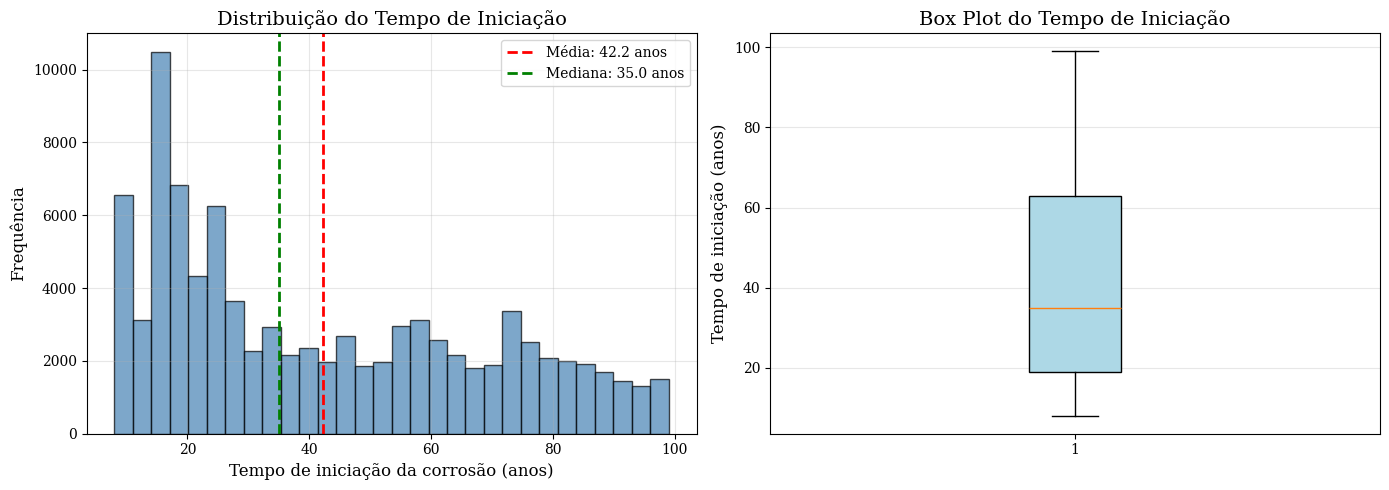

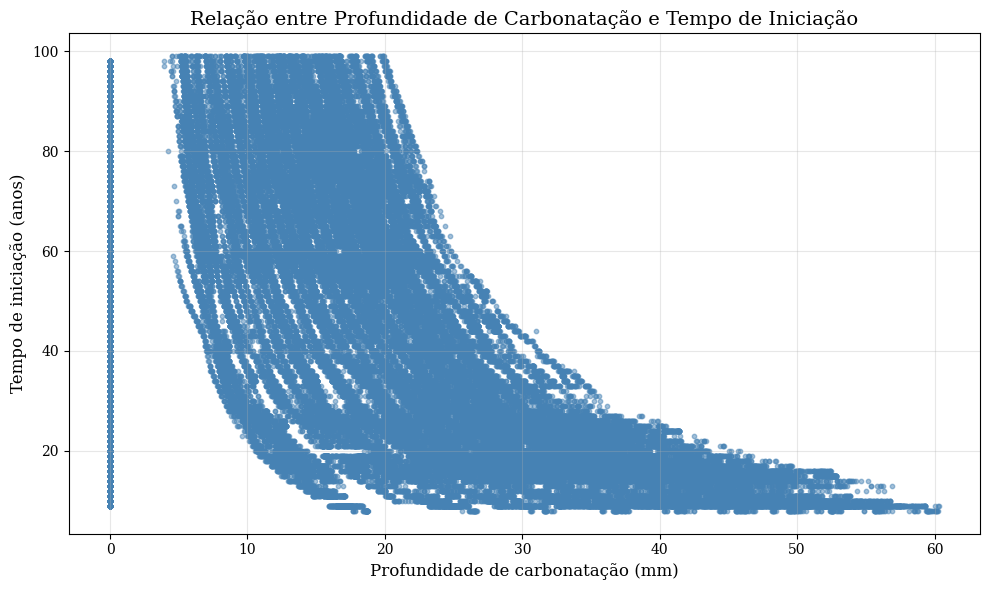

In [10]:
# Extrair tempos de iniciação dos resultados (agora cada amostra tem seu próprio t_carb)
initiation_times_all = []
carbonation_depths_all = []

for t, df in results.items():
    # Cada dataframe contém carbonation_times para cada amostra latente
    if 'Carbonation_time_years' in df.columns:
        initiation_times_all.extend(df['Carbonation_time_years'].values)
    if 'Carbonation_depth_mm' in df.columns:
        carbonation_depths_all.extend(df['Carbonation_depth_mm'].values)

# Converter para arrays numpy
initiation_times_all = np.array(initiation_times_all)
carbonation_depths_all = np.array(carbonation_depths_all)

# Remover valores infinitos (que nunca atingiram)
valid_initiation = initiation_times_all < lifetime_max
initiation_times_filtered = initiation_times_all[valid_initiation]

print(f"\n{'='*60}")
print("ANÁLISE DO TEMPO DE INICIAÇÃO DA CORROSÃO")
print(f"{'='*60}")
print(f"  Total de amostras analisadas: {len(initiation_times_all)}")
print(f"  Amostras que atingiram a armadura: {len(initiation_times_filtered)} ({100*len(initiation_times_filtered)/len(initiation_times_all):.1f}%)")
print(f"  Amostras que NÃO atingiram: {len(initiation_times_all) - len(initiation_times_filtered)}")
print(f"\n  Tempo de iniciação (amostras que atingiram):")
print(f"    Média: {np.mean(initiation_times_filtered):.2f} anos")
print(f"    Desvio padrão: {np.std(initiation_times_filtered):.2f} anos")
print(f"    Mediana: {np.median(initiation_times_filtered):.2f} anos")
print(f"    Percentis (5%, 95%): {np.percentile(initiation_times_filtered, [5, 95])}")

# Gráfico do tempo de iniciação
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(initiation_times_filtered, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(initiation_times_filtered), color='red', linestyle='--', 
                linewidth=2, label=f'Média: {np.mean(initiation_times_filtered):.1f} anos')
axes[0].axvline(np.median(initiation_times_filtered), color='green', linestyle='--', 
                linewidth=2, label=f'Mediana: {np.median(initiation_times_filtered):.1f} anos')
axes[0].set_xlabel('Tempo de iniciação da corrosão (anos)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].set_title('Distribuição do Tempo de Iniciação', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
bp = axes[1].boxplot(initiation_times_filtered, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('Tempo de iniciação (anos)', fontsize=12)
axes[1].set_title('Box Plot do Tempo de Iniciação', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tempo_iniciacao_analise.png', dpi=300, bbox_inches='tight')
plt.show()

# Gráfico adicional: relação entre profundidade e tempo de iniciação
plt.figure(figsize=(10, 6))
# Usar apenas amostras válidas
valid_for_scatter = valid_initiation & (carbonation_depths_all < 100)
plt.scatter(carbonation_depths_all[valid_for_scatter], 
           initiation_times_all[valid_for_scatter], 
           alpha=0.5, s=10, c='steelblue')
plt.xlabel('Profundidade de carbonatação (mm)', fontsize=12)
plt.ylabel('Tempo de iniciação (anos)', fontsize=12)
plt.title('Relação entre Profundidade de Carbonatação e Tempo de Iniciação', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('carb_depth_vs_initiation_time.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Organiza gs e extrai lambdas

In [11]:
time = sorted(results.keys())

gs = []  # Lista de DataFrames por tempo
lambdas = []  # Lista de parâmetros GLAM
stats_summary = []  # Lista para estatísticas resumidas

for t in time:
    df = results[t]
    
    # Garante que é DataFrame
    gs.append(df)
    
    # Extrai lambdas (são constantes dentro do df para cada realização)
    # Agora cada realização tem seus próprios lambdas, então pegamos a média
    lambda_cols = ['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']
    if all(col in df.columns for col in lambda_cols):
        # Calcular média dos lambdas (ignorando NaNs)
        lam_mean = []
        for col in lambda_cols:
            valid_vals = df[col][~np.isnan(df[col])]
            if len(valid_vals) > 0:
                lam_mean.append(valid_vals.mean())
            else:
                lam_mean.append(np.nan)
        lambdas.append(lam_mean)
        
        # Estatísticas adicionais
        stats_summary.append({
            'time': t,
            'n_samples': len(df),
            'P_failure': np.mean(df['g'] < 0),
            'g_mean': df['g'].mean(),
            'g_std': df['g'].std(),
            'R_mean': df['R'].mean(),
            'S_mean': df['S'].mean(),
            'lambda_1_mean': lam_mean[0],
            'lambda_2_mean': lam_mean[1],
            'lambda_3_mean': lam_mean[2],
            'lambda_4_mean': lam_mean[3]
        })
    else:
        lambdas.append([np.nan, np.nan, np.nan, np.nan])
        stats_summary.append({
            'time': t,
            'n_samples': len(df),
            'P_failure': np.mean(df['g'] < 0),
            'g_mean': df['g'].mean(),
            'g_std': df['g'].std(),
            'R_mean': df['R'].mean(),
            'S_mean': df['S'].mean(),
            'lambda_1_mean': np.nan,
            'lambda_2_mean': np.nan,
            'lambda_3_mean': np.nan,
            'lambda_4_mean': np.nan
        })

# Converter para array
lambdas = np.array(lambdas)

# Criar DataFrame com estatísticas resumidas
stats_df = pd.DataFrame(stats_summary)
print("\nEstatísticas Resumidas:")
print(stats_df.round(4))

# Salvar estatísticas
stats_df.to_csv('estatisticas_resultados.csv', index=False)


Estatísticas Resumidas:
    time  n_samples  P_failure   g_mean    g_std   R_mean   S_mean  \
0      0      10000     0.0010  12.8290   3.8410  44.4761  31.6471   
1     10      10000     0.0013  12.8795   3.8765  44.5106  31.6312   
2     20      10000     0.0338  11.4722   5.1211  43.1087  31.6365   
3     30      10000     0.2040   8.0579   7.9617  39.7647  31.7068   
4     40      10000     0.3644   4.9144  10.3360  36.5573  31.6429   
5     50      10000     0.4444   2.0641  11.9505  33.7112  31.6471   
6     60      10000     0.5146  -0.7938  13.2777  30.8820  31.6758   
7     70      10000     0.5918  -3.8023  13.9915  27.8235  31.6258   
8     80      10000     0.6616  -6.8166  14.4015  24.8142  31.6308   
9     90      10000     0.7381  -9.8800  14.3419  21.7489  31.6288   
10   100      10000     0.7913 -12.6665  14.1428  18.9999  31.6664   

    lambda_1_mean  lambda_2_mean  lambda_3_mean  lambda_4_mean  
0         12.9631         0.3672         0.1523         0.2215  
1   

## 11. GRÁFICO KDE (g ao longo do tempo)

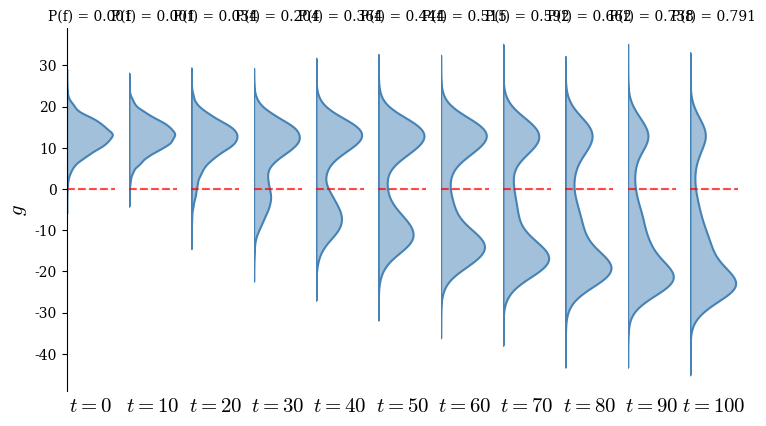

In [12]:
# Configurações da figura
dpi = 600
name = 'time-lapse_g_analysis'

b_cm_individual = 2.0
h_cm = 12
inches_to_cm = 1 / 2.54

n_plots = len(time)
b_input_total = (b_cm_individual * n_plots) * inches_to_cm
h_input = h_cm * inches_to_cm

label_y = '$g$'
size_label = 15
size_axis = 14
color = 'steelblue'
alpha = 0.5

# Figura
fig, axes = plt.subplots(
    nrows=1, 
    ncols=n_plots, 
    sharey=True, 
    figsize=(b_input_total, h_input)
)

plt.subplots_adjust(wspace=0.3)

# Loop para cada tempo
for i, ax in enumerate(axes):
    
    current_data = gs[i]
    
    # KDE plot com seaborn
    sns.kdeplot(
        y=current_data['g'], 
        fill=True, 
        alpha=alpha, 
        ax=ax, 
        color=color,
        linewidth=1.5
    )
    
    # Linha de falha
    ax.axhline(0, linestyle='--', linewidth=1.5, color='red', alpha=0.7)
    
    # Destacar região de falha
    ax.axhspan(-np.inf, 0, alpha=0.1, color='red')
    
    ax.set_xlabel(f'$t={int(time[i])}$', fontsize=size_label)
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    
    # Remover bordas
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    
    # Adicionar probabilidade de falha no título
    pf = stats_summary[i]['P_failure']
    ax.set_title(f'P(f) = {pf:.3f}', fontsize=10, pad=5)

    if i == 0:
        ax.set_ylabel(label_y, fontsize=size_label)
    else:
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='y', left=False)
        ax.set_ylabel('')

# Salvar
fig.savefig(f'z_{name}.png', dpi=dpi, bbox_inches='tight')
plt.show()

## 12. Gráficos dos lambdas

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

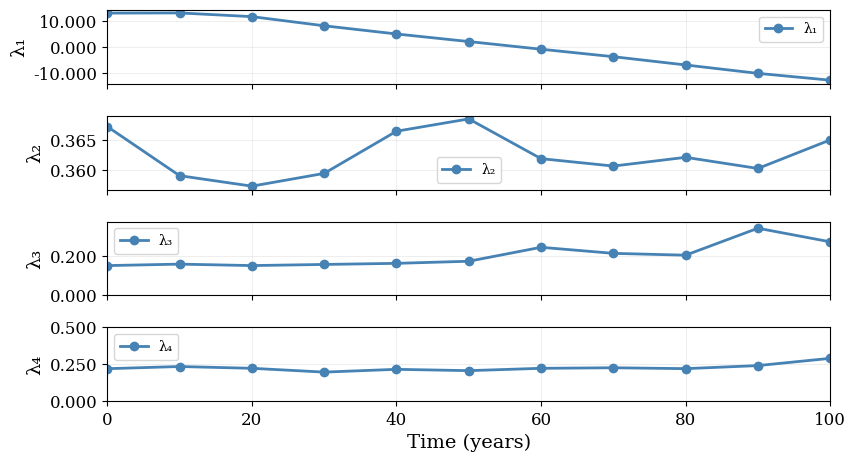

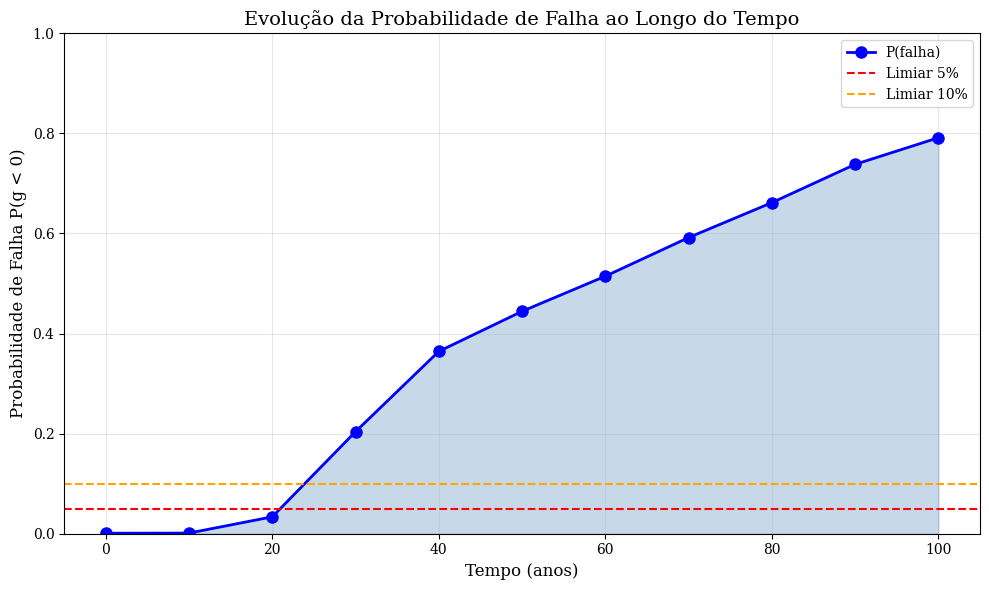


RESUMO FINAL

Análise de 100 amostras de projeto com 100 amostras latentes cada
Total de simulações: 110000

Probabilidade de falha por tempo:
  t =   0 anos: 0.0010 (0.10%)
  t =  10 anos: 0.0013 (0.13%)
  t =  20 anos: 0.0338 (3.38%)
  t =  30 anos: 0.2040 (20.40%)
  t =  40 anos: 0.3644 (36.44%)
  t =  50 anos: 0.4444 (44.44%)
  t =  60 anos: 0.5146 (51.46%)
  t =  70 anos: 0.5918 (59.18%)
  t =  80 anos: 0.6616 (66.16%)
  t =  90 anos: 0.7381 (73.81%)
  t = 100 anos: 0.7913 (79.13%)

Vida útil estimada (P(f) = 5%): 30 anos
Vida útil estimada (P(f) = 10%): 30 anos


In [15]:
# Preparar dados para plot
y1 = lambdas[:, 0]
y2 = lambdas[:, 1]
y3 = lambdas[:, 2]
y4 = lambdas[:, 3]

data = [
    {'x': time, 'y': y1, 'label': 'λ₁'},
    {'x': time, 'y': y2, 'label': 'λ₂'},
    {'x': time, 'y': y3, 'label': 'λ₃'},
    {'x': time, 'y': y4, 'label': 'λ₄'}
]

# Configurações
label_x = 'Time (years)'
size_label = 14
size_axis = 12
size_line = 2
style_line = '-'
color_line = 'steelblue'
marker = 'o'
size_marker = 6

# Figura com 4 subplots
fig, axes = plt.subplots(
    nrows=4, 
    ncols=1, 
    sharex=True, 
    figsize=(b_input_total, h_input)
)

# Plot
for ax, dataset in zip(axes, data):
    # Remover NaNs para plot
    valid_idx = ~np.isnan(dataset['y'])
    x_valid = np.array(dataset['x'])[valid_idx]
    y_valid = np.array(dataset['y'])[valid_idx]
    
    ax.plot(
        x_valid, y_valid,
        marker=marker,
        markersize=size_marker,
        linewidth=size_line,
        linestyle=style_line,
        color=color_line,
        label=dataset['label']
    )
    
    ax.tick_params(axis='both', which='major', labelsize=size_axis)
    ax.set_ylabel(dataset['label'], fontsize=size_label)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
    ax.legend(loc='best', fontsize=10)

# Ajuste específico (λ₃ e λ₄ costumam ser mais estáveis)
if len(y3[~np.isnan(y3)]) > 0:
    axes[2].set_ylim(0.0, max(0.3, y3.max() * 1.1))
if len(y4[~np.isnan(y4)]) > 0:
    axes[3].set_ylim(0.0, max(0.5, y4.max() * 1.1))

axes[-1].set_xlim(min(time), max(time))
axes[-1].set_xlabel(label_x, fontsize=size_label)

plt.tight_layout()
fig.savefig(f'z_lambdas_evolution.png', dpi=dpi, bbox_inches='tight')
plt.show()

# Gráfico adicional: evolução da probabilidade de falha
fig, ax = plt.subplots(figsize=(10, 6))

tempos = stats_df['time'].values
prob_falha = stats_df['P_failure'].values

ax.plot(tempos, prob_falha, 'b-o', linewidth=2, markersize=8, label='P(falha)')
ax.axhline(y=0.05, color='r', linestyle='--', linewidth=1.5, label='Limiar 5%')
ax.axhline(y=0.10, color='orange', linestyle='--', linewidth=1.5, label='Limiar 10%')
ax.fill_between(tempos, 0, prob_falha, alpha=0.3, color='steelblue')

ax.set_xlabel('Tempo (anos)', fontsize=12)
ax.set_ylabel('Probabilidade de Falha P(g < 0)', fontsize=12)
ax.set_title('Evolução da Probabilidade de Falha ao Longo do Tempo', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, max(1.0, prob_falha.max() * 1.1))

plt.tight_layout()
plt.savefig('probabilidade_falha_evolucao.png', dpi=300, bbox_inches='tight')
plt.show()

# Imprimir resumo final
print("\n" + "="*60)
print("RESUMO FINAL")
print("="*60)
print(f"\nAnálise de {len(x)} amostras de projeto com {n_latent_samples} amostras latentes cada")
print(f"Total de simulações: {len(x) * n_latent_samples * len(times)}")

print("\nProbabilidade de falha por tempo:")
for i, t in enumerate(tempos):
    print(f"  t = {t:3d} anos: {prob_falha[i]:.4f} ({prob_falha[i]*100:.2f}%)")

# Identificar vida útil (tempo para P(f) > 5%)
vida_util_5 = None
vida_util_10 = None
for t, pf in zip(tempos, prob_falha):
    if vida_util_5 is None and pf >= 0.05:
        vida_util_5 = t
    if vida_util_10 is None and pf >= 0.10:
        vida_util_10 = t

if vida_util_5:
    print(f"\nVida útil estimada (P(f) = 5%): {vida_util_5} anos")
if vida_util_10:
    print(f"Vida útil estimada (P(f) = 10%): {vida_util_10} anos")